# 대한민국 출생아수와 합계출산율 데이터 분석

이 노트북은 대한민국의 출생아수와 합계출산율 데이터를 클렌징하고 분석하는 과정을 보여줍니다.
- 데이터 클랜징
- 통계 분석
- 시각화

## 1. 필요한 라이브러리 가져오기

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['font.sans-serif'] = ['Malgun Gothic']
plt.rcParams['axes.unicode_minus'] = False

## 2. 엑셀 파일 불러오기

In [2]:
# 엑셀 파일 경로
file_path = '출생아수__합계출산율__자연증가_등_20260529172733.xlsx'

# 모든 시트 이름 확인
xls = pd.ExcelFile(file_path)
print("Sheet names:", xls.sheet_names)

# 첫 번째 시트 로드
df_raw = pd.read_excel(file_path, sheet_name=0)
print(f"\n원본 데이터 로드 완료: {df_raw.shape}")

Sheet names: ['데이터', '메타정보']

원본 데이터 로드 완료: (6, 4)


## 3. 원본 데이터 점검

In [3]:
# 데이터 프레임의 처음 5행 표시
print("=" * 80)
print("원본 데이터 (처음 5행)")
print("=" * 80)
print(df_raw.head())

print("\n" + "=" * 80)
print("데이터 정보")
print("=" * 80)
df_raw.info()

print("\n" + "=" * 80)
print("기본 통계")
print("=" * 80)
print(df_raw.describe())

print("\n" + "=" * 80)
print("결측치 확인")
print("=" * 80)
print(df_raw.isnull().sum())

print("\n" + "=" * 80)
print("컬럼명")
print("=" * 80)
print(df_raw.columns.tolist())

원본 데이터 (처음 5행)
        기본항목별        2023        2024   2025 p)
0     출생아수(명)  230028.000  238317.000  254457.0
1   자연증가건수(명) -122483.000 -120252.000 -108931.0
2   조출생률(천명당)       4.500       4.700       5.0
3  자연증가율(천명당)      -2.400      -2.400      -2.1
4    합계출산율(명)       0.721       0.748       0.8

데이터 정보
<class 'pandas.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   기본항목별    6 non-null      str    
 1   2023     6 non-null      float64
 2   2024     6 non-null      float64
 3   2025 p)  6 non-null      float64
dtypes: float64(3), str(1)
memory usage: 324.0 bytes

기본 통계
                2023           2024        2025 p)
count       6.000000       6.000000       6.000000
mean    17942.153500   19695.508000   24272.583333
std    114876.848766  117412.153403  120896.144706
min   -122483.000000 -120252.000000 -108931.000000
25%        -1.619750      -1.613000      -1.375000
50%   

## 4. 데이터 클랜징

In [11]:
# 데이터 복사
df = df_raw.copy()

print("데이터 클랜징 과정:")
print("-" * 80)

# 1. 컬럼명 정리 - 공백 제거 및 정규화
df.columns = df.columns.str.strip()
print(f"1. 컬럼명 정리 완료")
print(f"   컬럼: {df.columns.tolist()}")

# 2. 첫 번째 컬럼이 년도 정보인지 확인
print(f"\n2. 데이터 구조 확인")
print(df.head(10))

# 3. 불필요한 행 제거 (모두 NaN인 행)
df = df.dropna(how='all')
print(f"\n3. 빈 행 제거 완료: {df.shape[0]}행 남음")

# 4. 결측치 처리
print(f"\n4. 결측치 처리")
print(f"   클랜징 전 결측치: {df.isnull().sum().sum()}개")
# 숫자형 컬럼의 결측치는 0으로 채우거나 제거
df = df.dropna(subset=[df.columns[0]])  # 첫 번째 컬럼은 반드시 필요
print(f"   클랜징 후 결측치: {df.isnull().sum().sum()}개")

# 5. 데이터 타입 변환
# 첫 번째 컬럼은 지표 이름이므로 유지
for col in df.columns[1:]:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print(f"5. 데이터 타입 변환 완료")
print(f"   {df.dtypes}")

# 6. 연도별 형태로 전환
print(f"\n6. 연도별 형태로 전환")
df_year = df.set_index(df.columns[0]).T

df_year.index = df_year.index.astype(str).str.replace(' p)', '', regex=False).str.strip()

print(f"df_year shape: {df_year.shape}")
print(df_year.head())

print(f"\n클랜징 완료: {df.shape}")
print("\n클랜징된 데이터:")
print(df.head())

데이터 클랜징 과정:
--------------------------------------------------------------------------------
1. 컬럼명 정리 완료
   컬럼: ['기본항목별', '2023', '2024', '2025 p)']

2. 데이터 구조 확인
        기본항목별        2023        2024   2025 p)
0     출생아수(명)  230028.000  238317.000  254457.0
1   자연증가건수(명) -122483.000 -120252.000 -108931.0
2   조출생률(천명당)       4.500       4.700       5.0
3  자연증가율(천명당)      -2.400      -2.400      -2.1
4    합계출산율(명)       0.721       0.748       0.8
5     출생성비(명)     105.100     105.000     105.8

3. 빈 행 제거 완료: 6행 남음

4. 결측치 처리
   클랜징 전 결측치: 0개
   클랜징 후 결측치: 0개
5. 데이터 타입 변환 완료
   기본항목별          str
2023       float64
2024       float64
2025 p)    float64
dtype: object

6. 연도별 형태로 전환
df_year shape: (3, 6)
기본항목별   출생아수(명)  자연증가건수(명)  조출생률(천명당)  자연증가율(천명당)  합계출산율(명)  출생성비(명)
2023   230028.0  -122483.0        4.5        -2.4     0.721    105.1
2024   238317.0  -120252.0        4.7        -2.4     0.748    105.0
2025   254457.0  -108931.0        5.0        -2.1     0.800    105.8

클랜징 완료: (6,

## 5. 기본 통계 및 요약 분석

In [ ]:
print("=" * 80)
print("기본 통계 분석")
print("=" * 80)

# 년도 컬럼명 확인
year_col = df.columns[0]
print(f"\n년도 컬럼: {year_col}")
print(f"분석 기간: {df[year_col].min():.0f}년 ~ {df[year_col].max():.0f}년")

# 각 컬럼별 통계
print("\n" + "=" * 80)
print("컬럼별 통계")
print("=" * 80)
print(df.describe())

# 출생아수 관련 컬럼 찾기
print("\n" + "=" * 80)
print("출생아수 관련 정보")
print("=" * 80)
print(df.dtypes)

# 각 컬럼의 최대값, 최소값, 변화추이
print("\n" + "=" * 80)
print("주요 지표")
print("=" * 80)
for col in df.columns[1:]:
    if pd.api.types.is_numeric_dtype(df[col]):
        print(f"\n{col}:")
        print(f"  최대: {df[col].max():.2f} ({df.loc[df[col].idxmax(), year_col]:.0f}년)")
        print(f"  최소: {df[col].min():.2f} ({df.loc[df[col].idxmin(), year_col]:.0f}년)")
        print(f"  평균: {df[col].mean():.2f}")
        print(f"  표준편차: {df[col].std():.2f}")
        
        # 첫해와 마지막 해 비교
        first_val = df[col].iloc[0]
        last_val = df[col].iloc[-1]
        change = last_val - first_val
        change_pct = (change / first_val * 100) if first_val != 0 else 0
        print(f"  변화: {first_val:.2f} → {last_val:.2f} ({change:+.2f}, {change_pct:+.1f}%)")

## 6. 년도별 출생아수 분석

In [12]:
# 출생아수 컬럼 식별
data_cols = df_year.columns.tolist()

print("=" * 80)
print("년도별 출생아수 상세 분석")
print("=" * 80)

birth_col = '출생아수(명)'
if birth_col not in df_year.columns:
    birth_col = data_cols[0]

print(f"\n분석 대상: {birth_col}")
print(f"\n년도별 {birth_col}:")
print(df_year[[birth_col]].to_string())

# 년도별 증감
df_year['증감'] = df_year[birth_col].diff()
df_year['증감률(%)'] = df_year[birth_col].pct_change() * 100

print(f"\n년도별 증감 분석:")
print(df_year[[birth_col, '증감', '증감률(%)']].to_string())

print(f"\n5년 단위 변화:")
print("   데이터가 3년치만 있어서 5년 단위 변화를 계산할 수 없습니다.")

년도별 출생아수 상세 분석

분석 대상: 출생아수(명)

년도별 출생아수(명):
기본항목별   출생아수(명)
2023   230028.0
2024   238317.0
2025   254457.0

년도별 증감 분석:
기본항목별   출생아수(명)       증감    증감률(%)
2023   230028.0      NaN       NaN
2024   238317.0   8289.0  3.603474
2025   254457.0  16140.0  6.772492

5년 단위 변화:
   데이터가 3년치만 있어서 5년 단위 변화를 계산할 수 없습니다.


## 7. 년도별 출생아수 라인 그래프

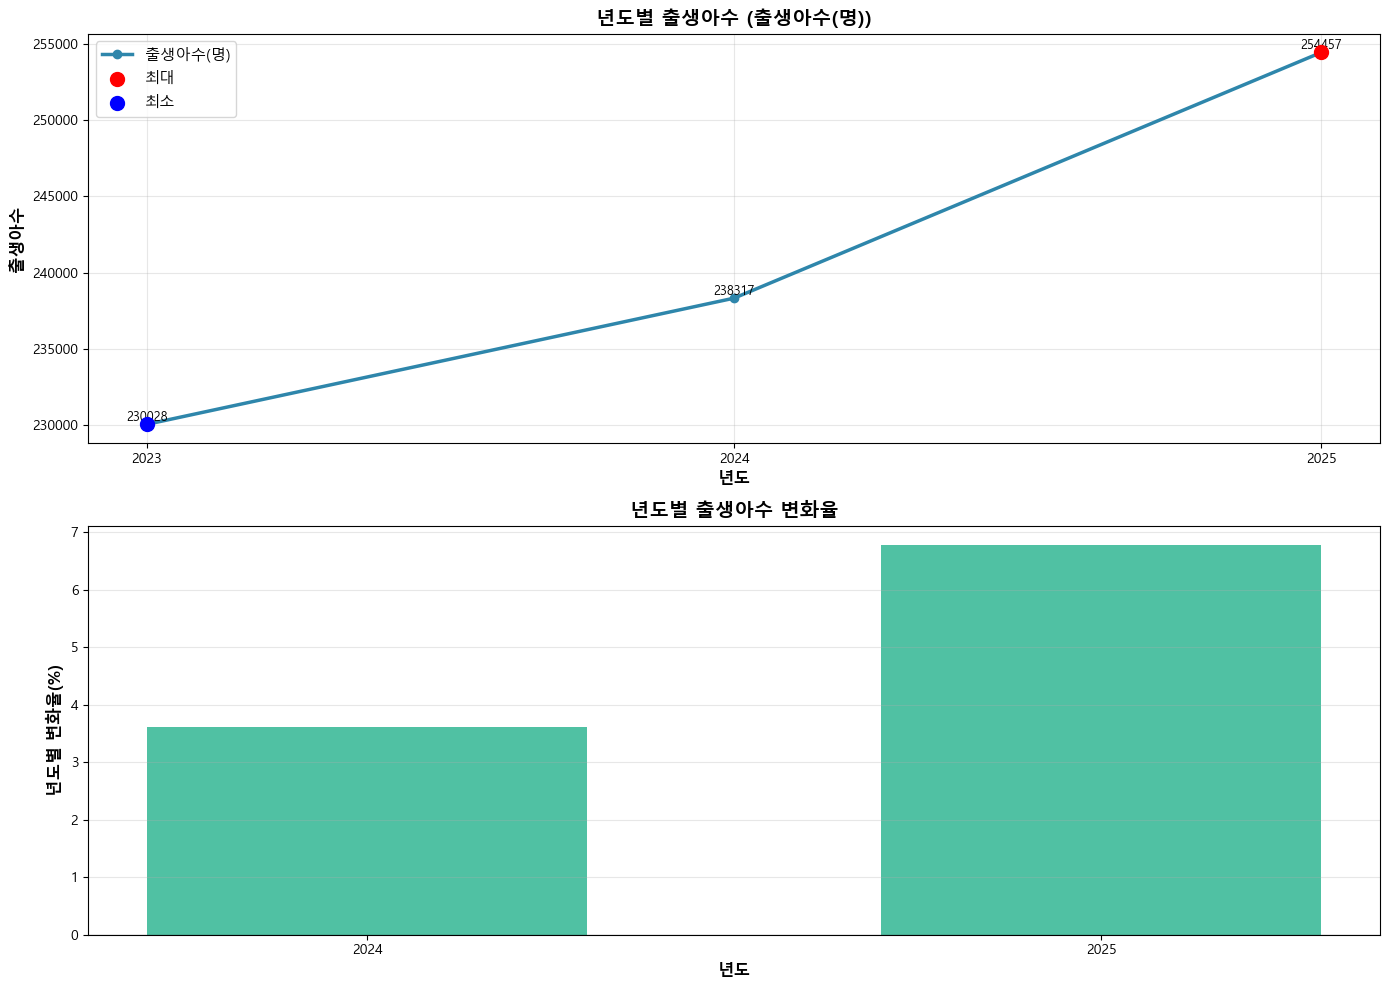


그래프 저장 완료: birth_analysis.png


In [13]:
# 라인 그래프 그리기
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# 1. 출생아수 라인 그래프
ax1 = axes[0]
ax1.plot(df_year.index, df_year[birth_col], marker='o', linewidth=2.5, markersize=6, 
         color='#2E86AB', label=birth_col)
ax1.set_xlabel('년도', fontsize=12, fontweight='bold')
ax1.set_ylabel('출생아수', fontsize=12, fontweight='bold')
ax1.set_title(f'년도별 출생아수 ({birth_col})', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=11)

# 최대/최소값 표시
max_idx = df_year[birth_col].idxmax()
min_idx = df_year[birth_col].idxmin()
ax1.scatter([max_idx], [df_year.loc[max_idx, birth_col]], 
           color='red', s=100, zorder=5, label='최대')
ax1.scatter([min_idx], [df_year.loc[min_idx, birth_col]], 
           color='blue', s=100, zorder=5, label='최소')
ax1.legend(fontsize=11)

# 값 표시
for year, value in zip(df_year.index, df_year[birth_col]):
    ax1.text(year, value, f'{value:.0f}', ha='center', va='bottom', fontsize=9)

# 2. 년도별 증감률 라인 그래프
ax2 = axes[1]
valid_change = df_year['증감률(%)'].dropna()
valid_years = df_year.index[1:]

colors = ['#06A77D' if x >= 0 else '#D62828' for x in valid_change]
ax2.bar(valid_years, valid_change, color=colors, alpha=0.7, width=0.6)
ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
ax2.set_xlabel('년도', fontsize=12, fontweight='bold')
ax2.set_ylabel('년도별 변화율(%)', fontsize=12, fontweight='bold')
ax2.set_title('년도별 출생아수 변화율', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('birth_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n그래프 저장 완료: birth_analysis.png")

### 추가 시각화: 모든 지표를 한눈에 보기

In [ ]:
# 모든 지표 시각화
fig, axes = plt.subplots(len(data_cols), 1, figsize=(14, 4*len(data_cols)))

# 축이 1개면 list가 아니므로 처리
if len(data_cols) == 1:
    axes = [axes]

for idx, col in enumerate(data_cols):
    ax = axes[idx]
    if pd.api.types.is_numeric_dtype(df_year[col]):
        ax.plot(df_year.index, df_year[col], marker='o', linewidth=2.5, markersize=6, 
                color=plt.cm.Set2(idx))
        ax.set_xlabel('년도', fontsize=11, fontweight='bold')
        ax.set_ylabel(col, fontsize=11, fontweight='bold')
        ax.set_title(f'년도별 {col}', fontsize=12, fontweight='bold')
        ax.grid(True, alpha=0.3)
        
        # 최대/최소값 강조
        max_idx = df_year[col].idxmax()
        min_idx = df_year[col].idxmin()
        ax.scatter([max_idx], [df_year.loc[max_idx, col]], 
                  color='red', s=80, zorder=5, alpha=0.7)
        ax.scatter([min_idx], [df_year.loc[min_idx, col]], 
                  color='blue', s=80, zorder=5, alpha=0.7)

plt.tight_layout()
plt.savefig('all_indicators_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("모든 지표 시각화 저장 완료: all_indicators_analysis.png")

## 분석 요약

In [ ]:
print("=" * 80)
print("분석 요약 보고서")
print("=" * 80)

print(f"\n1. 데이터 개요")
print(f"   - 분석 기간: {df[year_col].min():.0f}년 ~ {df[year_col].max():.0f}년")
print(f"   - 데이터 포인트: {len(df)}개")
print(f"   - 결측치: {df.isnull().sum().sum()}개 (클랜징 완료)")

print(f"\n2. {birth_col} 분석")
first_year = df[year_col].iloc[0]
last_year = df[year_col].iloc[-1]
first_val = df[birth_col].iloc[0]
last_val = df[birth_col].iloc[-1]
change = last_val - first_val
change_pct = (change / first_val * 100)

print(f"   - {first_year:.0f}년: {first_val:,.0f}명")
print(f"   - {last_year:.0f}년: {last_val:,.0f}명")
print(f"   - 총 변화: {change:+,.0f}명 ({change_pct:+.1f}%)")
print(f"   - 최대값: {df[birth_col].max():,.0f}명 ({df.loc[df[birth_col].idxmax(), year_col]:.0f}년)")
print(f"   - 최소값: {df[birth_col].min():,.0f}명 ({df.loc[df[birth_col].idxmin(), year_col]:.0f}년)")

print(f"\n3. 주요 트렌드")
if change_pct < 0:
    print(f"   - 출생아수 감소 추세: 전체 기간 동안 {abs(change_pct):.1f}% 감소")
else:
    print(f"   - 출생아수 증가 추세: 전체 기간 동안 {change_pct:.1f}% 증가")

# 최근 5년 추세
if len(df) >= 5:
    recent_first = df[birth_col].iloc[-5]
    recent_last = df[birth_col].iloc[-1]
    recent_change = ((recent_last - recent_first) / recent_first * 100)
    print(f"   - 최근 5년 변화: {recent_change:+.1f}%")

print(f"\n4. 데이터 품질")
print(f"   - 전체 데이터: {len(df)}행")
print(f"   - 유효한 데이터: {df[birth_col].notna().sum()}행")
print(f"   - 데이터 완성도: {(df[birth_col].notna().sum()/len(df)*100):.1f}%")

print("\n" + "=" * 80)
print("분석 완료!")
print("=" * 80)